# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [20]:
#Install required libraries (uncomment if needed)
!pip install datasets scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim
import nltk
nltk.download('punkt_tab', quiet=True)

True

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [22]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [23]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("fancyzhx/ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...
Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [24]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [25]:
# TODO: Train a Logistic Regression classifier on AG News
# 1. Create the classifier
# 2. Train it
# 3. Make predictions
# 4. Calculate accuracy and F1-score (macro)

clf_ag = LogisticRegression(max_iter=1000, C=10)

# Train
clf_ag.fit(X_train_ag, y_train_ag)


# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8580
  F1 (macro): 0.8574


In [26]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.88      0.85      0.87       493
      Sports       0.93      0.94      0.93       504
    Business       0.80      0.80      0.80       474
    Sci/Tech       0.82      0.84      0.83       529

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [27]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...
Train: 1500, Test: 500

Columns: ['text', 'labels']


In [28]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [29]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [30]:
# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=5000,      # Choose: 3000-5000
    ngram_range=(1, 2),       # Choose: (1,1), (1,2), or (1,3)
    min_df=3,            # Choose: 2-5
    max_df=0.95           # Choose: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [31]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(C=1.0, class_weight='balanced')  # Create LinearSVC

# Train
clf_legal.fit(X_train_lex, y_train_lex)
# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6402
  F1 (macro): 0.4984


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: 0.8580 accuracy / 0.8574 macro-F1  |  Legal (ECtHR): 0.6402 accuracy / 0.4984 macro-F1
   - Reason for difference: AG News reaches much higher scores because it has only 4 well separated, balanced topics on short, clean texts, so a linear model on TF-IDF discriminates them easily. The legal task is intrinsically harder: I reduced a multi-label problem to a single "primary" label, there are many classes, the distribution is heavily imbalanced, and the documents are long and truncated to 5000 characters. A revealing sign is the gap on the legal task between accuracy (0.64) and macro-F1 (0.50): the model does well on the frequent classes (which inflates accuracy) but poorly on the rare ones (which drags down the macro-F1). On AG News, accuracy and macro-F1 are almost identical (0.858 vs 0.857), confirming the classes are balanced.

2. My vectorizer choices:
   - max_features=5000 because legal text has a huge vocabulary; keeping the 5000 most frequent terms controls dimensionality and noise while retaining the signal bearing words.
   - ngram_range=(1,2) because legal meaning often lives in fixed phrases ("human rights", "fair trial", "freedom of expression"); bigrams capture these multi word concepts that unigrams miss.
   - min_df=3 because terms appearing in fewer than 3 documents are usually OCR artefacts, citation numbers or one-off names that only add noise and overfitting risk.
   - max_df=0.95 because words present in almost every document (legal boilerplate: "court", "article", "applicant") carry little discriminative power, so dropping the top 5% sharpens the features.


3. Legal classification challenges:
   - Length: documents are far longer than news; truncation to 5000 characters loses information and key facts may sit beyond the cut-off.
   - Vocabulary: highly specialised, with Latin terms, citations and references that are domain specific and sparse.
   - Ambiguity / multi-label nature: a single case can violate several articles at once, so forcing one "primary" label discards real structure and confuses the model.
   - Class imbalance: a handful of articles account for most cases, so the classifier is biased toward majority classes and the rare ones get near-zero recall exactly what the low macro-F1 (0.4984) reflects.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [36]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("SetFit/amazon_reviews_multi_en")
# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_train['stars']=amazon_train['label']

amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)
amazon_test['stars']=amazon_test['label']

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")

print(amazon_train['stars'].value_counts().sort_index())

Loading Amazon Reviews dataset...
Train: 5000, Test: 1000

Columns: ['id', 'text', 'label', 'label_text', 'stars']

Star rating distribution:
stars
0    1007
1     982
2    1003
3     987
4    1021
Name: count, dtype: int64


In [37]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4013, Test: 790

Sentiment distribution:
sentiment
0    2992
1    1021
Name: count, dtype: int64


In [42]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Review: {pos_sample['text'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Review: {neg_sample['text'][:300]}...")

Sample POSITIVE review:
Review: These bags have a lot of space in them, good thing about these bags is that I can easily see what's inside then. Very reasonable price....


Sample NEGATIVE review:
Review: Not strong enough to run a small 120v vacuum cleaner, to clean car....


### Exercise B.1: Build Amazon Sentiment Classifier

In [44]:
# TODO: Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['text'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['text'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)


X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: YOUR CODE HERE - Train Naive Bayes and evaluate or choose another model if not suitable
clf_amazon = MultinomialNB(alpha=0.5)

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8709

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      1.00      0.92       598
    Positive       0.99      0.47      0.64       192

    accuracy                           0.87       790
   macro avg       0.92      0.74      0.78       790
weighted avg       0.89      0.87      0.85       790



In [45]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['works like', 'love it', 'just what', 'quality for', 'fast shipping', 'very nice', 'definitely recommend', 'great price', 'perfect for', 'amazing', 'loves', 'great buy', 'loves it', 'exactly what', 'highly recommend']

Top NEGATIVE words: ['broken', 'never received', 'waste', 'broke', 'returned', 'return', 'very disappointed', 'cheap', 'disappointed', 'poor', 'not sure', 'smaller than', 'not fit', 'stopped working', 'never']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [47]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("ia-bentebib/tweet_eval_sentiment_fr")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['labels'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['labels'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


dataset_infos.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.01M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/941k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [50]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['labels'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: Je veux voir John Cena gagner son 16ème titre.

[Neutral]: "Ben Smith / Smith (commotion) reste hors de la gamme jeudi, Curtis #NHL #SJ"

[Positive]: "QT @user Dans l'ébauche originale du 7ème livre, Remus Lupin a survécu à la bataille des Hogwarts. #HappyBirthdayRemusLupin"



In [51]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user Dans l'ébauche originale du 7ème livre, Remus Lupin a survécu à la bataille des Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user dans lbauche originale du me livre remus lupin a survcu la bataille des hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [53]:
# TODO: Build a classifier using character n-grams (good for short, informal text)

# YOUR CODE HERE: Create a vectorizer with character n-grams
# Hint: Use analyzer='char_wb' for word-boundary-aware character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',           # 'char_wb' for character n-grams with word boundaries
    ngram_range=(2, 5),        # Try (2,5) or (3,6) for character n-grams
    max_features=5000,       # 3000-5000
    min_df=3             # 2-5
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['labels']
y_test_tw = tweet_test['labels']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [54]:
# TODO: Train Logistic Regression and evaluate

clf_tweet = LogisticRegression(max_iter=1000, C=10, class_weight='balanced')

# Train and predict
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)
# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5507
  F1 (macro): 0.5483

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.66      0.58      3972
     Neutral       0.63      0.47      0.54      5937
    Positive       0.49      0.57      0.53      2375

    accuracy                           0.55     12284
   macro avg       0.54      0.57      0.55     12284
weighted avg       0.57      0.55      0.55     12284



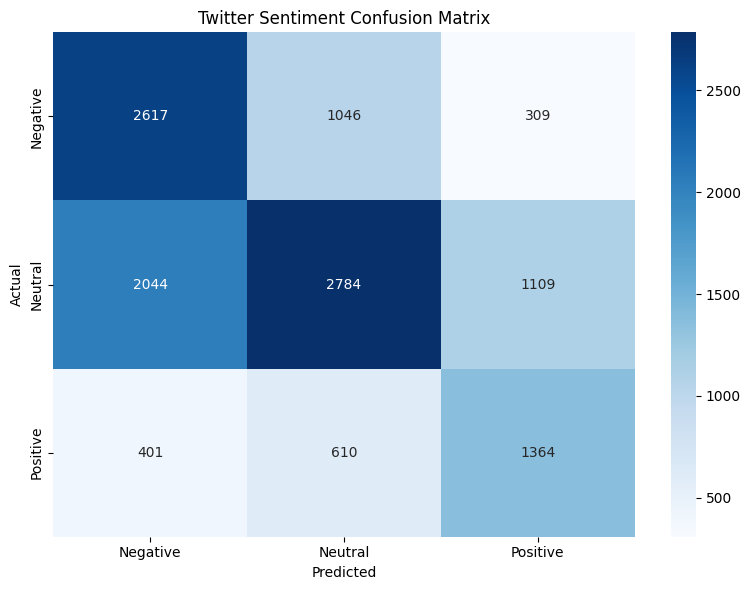

In [55]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon: accuracy 0.8709, macro-F1 0.78  |  Twitter: accuracy 0.5507, macro-F1 0.5483
   - Reason: Twitter is clearly harder. Amazon is a binary problem (I removed the neutral 3-star reviews) on relatively long, explicit reviews with strong sentiment words, so the model reaches a high macro-F1. Twitter is a 3-class problem that includes a fuzzy "neutral" category, on very short, noisy, informal text (slang, hashtags, mentions, sarcasm); its macro-F1 is ~0.23 lower. Note that Amazon is not perfect either: my sampled binary set is imbalanced (598 Negative vs 192 Positive), which is why Positive recall is only 0.47 despite the high overall accuracy — but it remains far easier than Twitter.

2. Character n-gram choices:
   - ngram_range=(2,5) with analyzer='char_wb' because tweets are short and full of misspellings, slang and lengthened words ("soooo good"); 2-to-5-character chunks generalise across these spelling variants and capture sub-word patterns, while 'char_wb' keeps the n-grams aware of word boundaries.
   - Advantage over words: word n-grams treat "good", "gooood" and "goood" as three unrelated tokens and break on out-of-vocabulary slang. Character n-grams share substrings across these variants, are robust to typos, and need no clean tokenisation — ideal for informal social-media text.

3. Most confused class:
   - ngram_range=(2,5) with analyzer='char_wb' because tweets are short and full of misspellings, slang and lengthened words ("soooo good"); 2-to-5-character chunks generalise across these spelling variants and capture sub-word patterns, while 'char_wb' keeps the n-grams aware of word boundaries.
   - Advantage over words: word n-grams treat "good", "gooood" and "goood" as three unrelated tokens and break on out-of-vocabulary slang. Character n-grams share substrings across these variants, are robust to typos, and need no clean tokenisation — ideal for informal social-media text.

4. Difficult tweet example:
   - Tweet: "Oh great, another Monday. Exactly what I needed."
   - Why it's hard: it is sarcastic — the surface words ("great", "exactly what I needed") are positive, but the intended sentiment is negative. A bag-of-character-n-grams model has no notion of irony or context, so it will most likely predict Positive when the true label is Negative.
C'est prêt à coller. Il te reste la Partie C (topic modeling ArXiv + contrats juridiques) — dis-moi quand tu y arrives, et pense aux préfixes armanc/scientific_papers et au chargement

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [58]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("JYumeko/processed_scientific_papers")

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


README.md:   0%|          | 0.00/730 [00:00<?, ?B/s]

data/train-00000-of-00004-978e6ec0a265a1(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

data/train-00001-of-00004-02ade3907565cb(…):   0%|          | 0.00/197M [00:00<?, ?B/s]

data/train-00002-of-00004-05dba117cf446a(…):   0%|          | 0.00/198M [00:00<?, ?B/s]

...

data/test-00000-of-00001-856c70c456c1b55(…):   0%|          | 0.00/44.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]

Loaded 2000 papers
Columns: ['abstract', 'summary']


In [59]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
long term synaptic plasticity thought represent cellular basis learning memory brain circuits since discovery early 1970s various mechanisms sites expression have described detail however spatiotemporal distribution synaptic plasticity poorly investigated despite fact reorganization synaptic weights following long term potentiation ltp long term depression ltd fundamental tuning signal transfer regulating homeostatic processes distributed networks 3 4 investigation spatiotemporal organization sy


In [61]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.9
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 1000)


In [65]:
# Train LDA model
n_topics_arxiv = 7  # Scientific papers likely have diverse topics. Choose appropriately (8-12).

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [66]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: study, group, age, level, subject, patient, score, significant, woman, control, difference, test
Topic 1: group, using, used, study, value, time, sample, result, concentration, different, mean, method
Topic 2: patient, study, treatment, group, disease, therapy, cancer, clinical, month, day, year, rate
Topic 3: gene, protein, using, sample, figure, data, analysis, dna, sequence, binding, two, one
Topic 4: health, study, research, data, care, cost, time, also, year, model, population, one
Topic 5: patient, case, tumor, lesion, left, right, surgery, may, year, bone, reported, diagnosis
Topic 6: cell, mouse, expression, protein, level, response, also, receptor, tissue, figure, effect, type


### Exercise C.1: Interpret ArXiv Topics

In [68]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
    0: "Clinical Studies & Epidemiology",
    1: "Lab Methods & Measurements",
    2: "Cancer Treatment & Clinical Therapy",
    3: "Genomics & Molecular Biology",
    4: "Public Health & Healthcare Policy",
    5: "Surgery & Clinical Case Reports",
    6: "Cell Biology & Gene Expression",
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Clinical Studies & Epidemiology
  Topic 1: Lab Methods & Measurements
  Topic 2: Cancer Treatment & Clinical Therapy
  Topic 3: Genomics & Molecular Biology
  Topic 4: Public Health & Healthcare Policy
  Topic 5: Surgery & Clinical Case Reports
  Topic 6: Cell Biology & Gene Expression


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [72]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("hugsid/legal-contracts")

print(legal_stream)

# Take first 1500 contracts
legal_df = pd.DataFrame(legal_stream["train"]).head(1500)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 26539
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3807
    })
    test: Dataset({
        features: ['text'],
        num_rows: 7680
    })
})
Loaded 1500 contracts


In [73]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
supplement joinder agreement agreement dated september made among triangle capital corporation maryland corporation borrower guarantor party credit agreement referred branch banking trust company administrative agent swingline lender existing lender pursuant credit agreement administrative agent uni


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [77]:
# TODO: Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal = None

tfidf_legal = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2)
)
#each row is a contract, each column is a term, each value is that term's importance in that contract.
dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")


Legal document-term matrix: (1500, 1000)


In [78]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 7  # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 7 topics...
Done!


In [79]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 7 topics):
Topic 0: agent, administrative agent, administrative, lender, borrower, shall, may, time, agent lender, payment, agent shall, notice
Topic 1: subsidiary, person, company, indebtedness, asset, consolidated, property, financial, material, company subsidiary, business, insurance
Topic 2: rate, interest, day, rate loan, interest period, period, loan, eurodollar, eurodollar rate, base, advance, base rate
Topic 3: lender, line, swing, swing line, defaulting lender, defaulting, commitment, assignment, shall, loan, obligation, amount
Topic 4: plan, erisa, code, section code, section, section erisa, pension, erisa affiliate, pension plan, expected, reasonably expected, multiemployer plan
Topic 5: credit, letter credit, letter, issuer, amount, bank, issuing, issuing bank, credit agreement, applicable issuer, time, revolving
Topic 6: party, document, loan, agreement, loan document, loan party, obligation, action, transaction, law, hereby, provision


In [88]:
# TODO: Assign labels to legal topics
my_legal_topic_labels = {
    0: "Administrative Agent & Lender-Borrower Mechanics",
    1: "Corporate Structure & Financial Covenants",
    2: "Interest Rates & Loan Pricing (Eurodollar/Base)",
    3: "Swing Line & Defaulting Lender Provisions",
    4: "ERISA & Pension / Benefit Plans",
    5: "Letters of Credit & Issuing Banks",
    6: "General Loan Documents & Contract Provisions",
}

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Administrative Agent & Lender-Borrower Mechanics
  Topic 1: Corporate Structure & Financial Covenants
  Topic 2: Interest Rates & Loan Pricing (Eurodollar/Base)
  Topic 3: Swing Line & Defaulting Lender Provisions
  Topic 4: ERISA & Pension / Benefit Plans
  Topic 5: Letters of Credit & Issuing Banks
  Topic 6: General Loan Documents & Contract Provisions


### Exercise C.3: Topic Distribution Visualization

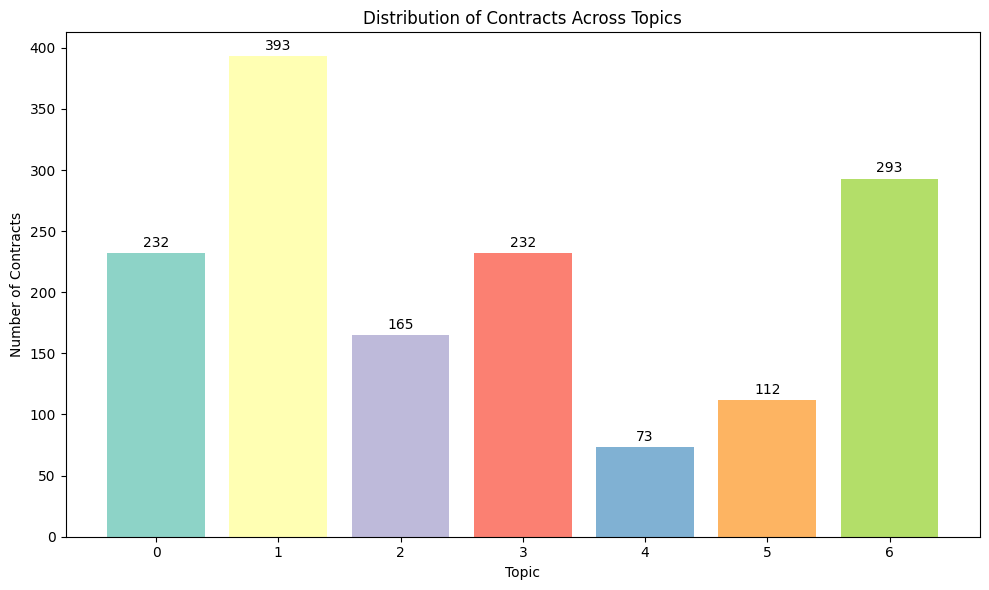

In [89]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: ArXiv (LDA)
   - Reason: Its topics come from very different sub fields (oncology, genomics, public health, surgery...), so each has its own distinctive vocabulary. The legal NMF topics all belong to one genre (credit/loan agreements) and share heavy boilerplate ("lender", "loan", "shall"), so the differences are subtle and harder to label.

2. Legal topic distribution:
   - Balanced? No  it's uneven: Topic 1 dominates (393), Topic 6 (293) and Topics 0 & 3 (232) are large, while Topic 4 / ERISA has only 73.
   - What this indicates: The dataset is one homogeneous contract family (loan agreements), not contracts in general. Generic financial/corporate clauses appear everywhere, while specialized clauses like ERISA are rare.

3. Topic refinement suggestions:
   - ArXiv Merge: Topics 3 and 6 because both are molecular/cell biology (gene, protein, DNA vs. cell, expression, receptor) and overlap heavily.
   - ArXiv  Split: Topic 2 because it mixes oncology terms (tumor, cancer, therapy) with generic clinical-trial terms (group, month, rate).
   - Legal - Merge: Topics 0 and 3 because both describe lender/agent administrative mechanics (administrative agent, borrower vs. swing line, defaulting lender).
   - Legal Split: Topic 6 because it's a vague catch-all (party, document, obligation, law) that bundles several distinct clause types (governing law, representations, general obligations)

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
